In [41]:
import numpy as np
import pandas as pd

import pandana
print(pandana.__version__)
pd.options.display.float_format = '{:.2f}'.format
from pandana.loaders import osm

import warnings
warnings.filterwarnings('ignore')
network = osm.pdna_network_from_bbox(37.698, -122.517, 37.819, -122.354)  # San Francisco, CA
network.nodes_df.to_csv('nodes.csv')
network.edges_df.to_csv('edges.csv')
nodes = pd.read_csv('nodes.csv', index_col=0)
edges = pd.read_csv('edges.csv', index_col=[0,1])

network = pandana.Network(nodes['x'], nodes['y'], 
                          edges['from'], edges['to'], edges[['distance']] / 80)

hospitals = osm.node_query(
    37.698, -122.517, 37.819, -122.354, tags='"amenity"="hospital"')

res = hospitals.sample(2)

network.set_pois(category = 'hospitals',
                 maxdist = 100,
                 maxitems = 3,
                 x_col = hospitals.lon, 
                 y_col = hospitals.lat)

0.7
Requesting network data within bounding box from Overpass API in 1 request(s)
Posting to http://www.overpass-api.de/api/interpreter with timeout=180, "{'data': '[out:json][timeout:180];(way["highway"]["highway"!~"motor|proposed|construction|abandoned|platform|raceway"]["foot"!~"no"]["pedestrians"!~"no"](37.69800000,-122.51700000,37.81900000,-122.35400000);>;);out;'}"
Downloaded 37,307.5KB from www.overpass-api.de in 2.81 seconds
Downloaded OSM network data within bounding box from Overpass API in 1 request(s) and 3.32 seconds
Returning OSM data with 198,255 nodes and 51,942 ways...
Edge node pairs completed. Took 11.22 seconds
Returning processed graph with 66,818 nodes and 98,790 edges...
Completed OSM data download and Pandana node and edge table creation in 15.89 seconds
Generating contraction hierarchies with 32 threads.
Setting CH node vector of size 66818
Setting CH edge vector of size 99350
Range graph removed 2658 edges of 198700
. 10% . 20% . 30% . 40% . 50% . 60% . 70% . 

<a id='section4'></a>

## Accessibility

### How many restaurants are within 500 meters of each node?

Pandana calls this kind of calculation an *aggregation*. It requires passing a list of network nodes and associated values. 

In this case, the "value" is just presence of a restaurant, but it could also be characteristics like square footage of a building or income of a household.

- [network.get_node_ids()](http://udst.github.io/pandana/network.html#pandana.network.Network.get_node_ids)
- [network.set()](http://udst.github.io/pandana/network.html#pandana.network.Network.set_pois)

In [42]:
hospital_nodes = network.get_node_ids(hospitals.lon, hospitals.lat)

In [43]:
network.set(hospital_nodes, 
            name = 'hospitals')

Now we can run the query.

- [network.aggregate()](http://udst.github.io/pandana/network.html#pandana.network.Network.aggregate)

In [58]:
accessibility = network.aggregate(distance = 60,
                                  type = 'sum',
                                  decay= 'flat',
                                  name = 'hospitals')
accessibility.describe()

60.0 b'hospitals' b'sum' b'flat' 0


count   66818.00
mean        1.60
std         1.00
min         0.00
25%         1.00
50%         2.00
75%         2.00
max         4.00
dtype: float64

Note that you can also calculate means, sums, percentiles, and other metrics, as well as applying linear or exponential "decay" to more distant values.

In [59]:
gravity = network.aggregate(distance = 60,
                                  type = 'sum',
                                  name = 'hospitals',
                                  imp_name='distance',
                                  decay='friction_curve')
gravity.describe()

60.0 b'hospitals' b'sum' b'friction_curve' 0


count   66818.00
mean      967.97
std      3141.57
min         0.00
25%       177.10
50%       354.20
75%       531.30
max     26706.31
dtype: float64

<a id='section5'></a>

## Visualization

Pandana's built-in `plot` function uses an older Matplotlib extension called Basemap that's now difficult to install. So here we'll just use Matplotlib directly.

### Mapping restaurant accessibility

In [60]:
import matplotlib
from matplotlib import pyplot as plt

print(matplotlib.__version__)

3.9.4


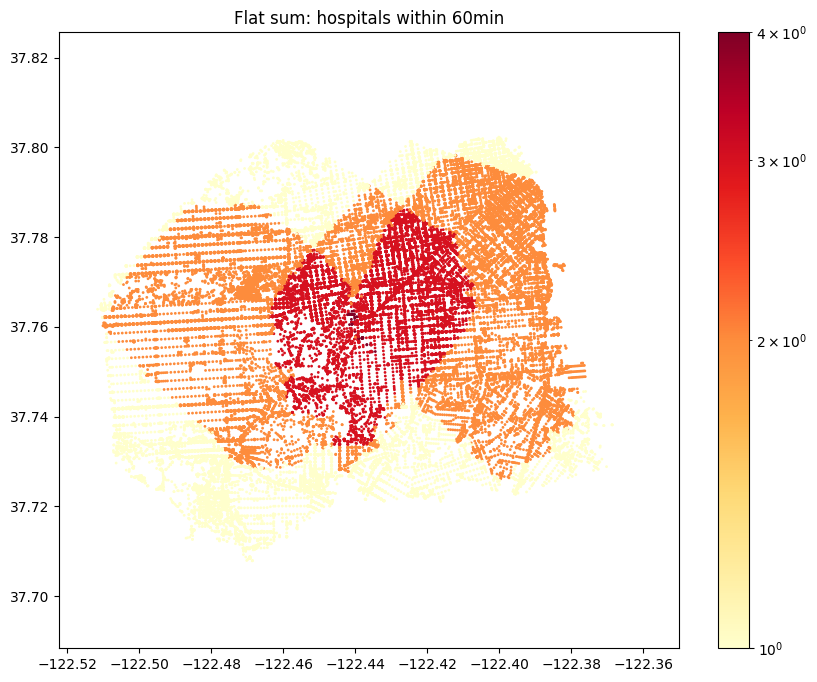

In [63]:
fig, ax = plt.subplots(figsize=(10,8))

plt.title('Flat sum: hospitals within 60min')
plt.scatter(network.nodes_df.x, network.nodes_df.y, 
            c=accessibility, s=1, cmap='YlOrRd', 
            norm=matplotlib.colors.LogNorm())
cb = plt.colorbar()

plt.show()

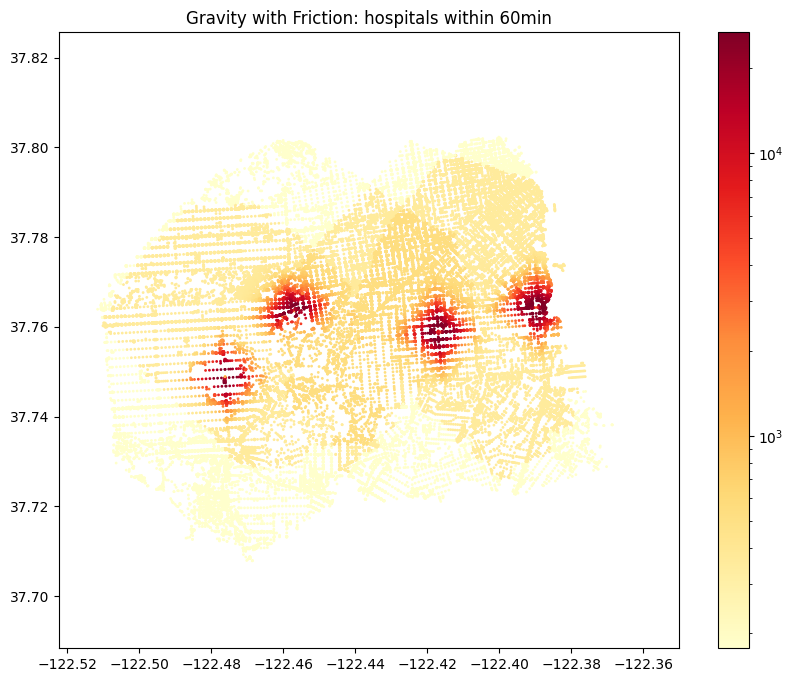

In [62]:
fig, ax = plt.subplots(figsize=(10,8))

plt.title('Gravity with Friction: hospitals within 60min')
plt.scatter(network.nodes_df.x, network.nodes_df.y, 
            c=gravity, s=1, cmap='YlOrRd', 
            norm=matplotlib.colors.LogNorm())
cb = plt.colorbar()

plt.show()

In [37]:
accessibility.describe()

count   66818.00
mean       28.41
std        38.22
min         0.00
25%         3.00
50%        13.00
75%        39.00
max       222.00
dtype: float64

In [38]:
gravity.describe()

count     66818.00
mean     327836.22
std      471368.66
min           0.00
25%       31406.57
50%      140912.49
75%      435294.37
max     3497928.83
dtype: float64